<a href="https://colab.research.google.com/github/adryamorim/GeoAnalise/blob/main/Intelig%C3%AAncia_Territorial_Aplicada_ao_Desenvolvimento_RegionalV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# TCC: INTELIGÊNCIA TERRITORIAL E VIABILIDADE DE DESENVOLVIMENTO (ISVT)
MÓDULO DE ANÁLISE - DIMENSÃO 1: FOMENTO FINANCEIRO (SICOR/BACEN)


Este script  carrega a base de dados anualizada (WIDE), realiza o cruzamento espacial com
as malhas do IBGE e conduz uma análise estatística e cartográfica completa.

--------------------------------------------------------------------------------
TEORIA E METODOLOGIA DO INDICADOR DE FOMENTO NORMALIZADO (0 a 1)
--------------------------------------------------------------------------------
1. O QUE É ESTE INDICADOR?
   O "indicador_fomento_normalizado" (ind_ANO) é um indicador sintético que
   expressa a força e a capilaridade do crédito rural formalizado e espacializado
   no território. Ele padroniza o volume total de recursos agrícolas contratados
   em cada município em uma escala comum de 0 a 1 usando a Normalização Min-Max.

2. POR QUE NORMALIZAR? (Justificativa Teórica)
   No modelo multicritério do ISVT, você precisará cruzar o crédito rural (medido
   em Reais) com dados de turismo (avaliações) e infraestrutura (cobertura 4G/5G).
   A normalização elimina a disparidade de unidades de medida, trazendo todas as
   variáveis para a mesma escala matemática de análise.

3. MOTIVAÇÃO CIENTÍFICA (A Visão da CEPAL e do Desenvolvimento Regional)
   A distribuição do crédito rural no Brasil é marcada por uma profunda
   "Heterogeneidade Estrutural" (Aníbal Pinto / CEPAL). Enquanto polos de
   exportação captam somas bilionárias, pequenas regiões de agricultura familiar
   sobrevivem com fomento mínimo. Mapear essa assimetria permite expor o papel do
   Estado e do sistema financeiro (incluindo BRDE, BNB e Cooperativas de Crédito)
   na reprodução das desigualdades regionais e na sustentação de economias locais
   (Araújo, 2018; Fochezatto, 2026).

4. COMO INTERPRETAR O RESULTADO?
   - Valor 1.0: O município polo que mais captou crédito rural no ano analisado.
   - Valor 0.0: O município com a menor captação de recursos no mesmo período.
   - Valores decimais muito baixos (ex: 0.002): Revelam a "cauda longa" da
     distribuição. Devido à presença de municípios gigantes que distorcem o topo,
     a maioria esmagadora das cidades ativas aparece com indicadores decimais
     baixos, refletindo a altíssima concentração espacial do fomento.


# Índice Sintético de Viabilidade Territorial (ISVT)
## Dimensão 1: Fomento Financeiro e Densidade de Capital (SICOR + BNDES)

Este módulo operacionaliza o cálculo da **Dimensão 1 (Fomento Financeiro)** do ISVT, comparando de forma multidimensional as estruturas de financiamento e investimento público nos municípios da **Bahia (BA)** e do **Rio Grande do Sul (RS)**.

### 1. Justificativa Teórica e Metodológica
A distribuição espacial de capital e fomento é historicamente assimétrica no território brasileiro. Para mensurar essa densidade financeira de maneira cientificamente rigorosa, este modelo integra duas bases de dados governamentais complementares, apoiando-se na teoria macroeconômica pós-keynesiana:
*   **SICOR (Banco Central):** Captura o crédito rural de varejo e a provisão de liquidez de curto prazo (*Finance*). É a força motriz que irriga a agricultura familiar, cooperativas e pequenos produtores agrícolas fundamentais para o desenvolvimento rural e o turismo de base comunitária.
*   **BNDES (Desembolsos Municipais):** Captura o crédito de fomento regional e o investimento estruturante de longo prazo (*Funding*). Representa os aportes direcionados para infraestrutura, saneamento, comércio, hotelaria e serviços.

A união dessas forças impede vieses analíticos que favoreceriam apenas centros urbanos ou polos puramente agrícolas, estabelecendo uma métrica holística de fomento financeiro.

### 2. Rigor Matemático e Tratamento de Dados
O pipeline de dados foi desenvolvido para ser executado de forma 100% offline e eficiente no Google Colab, respeitando as seguintes premissas científicas:
1.  **Validação de Consistência AHP (Saaty):** Em vez de ponderações arbitrárias, os pesos das variáveis são derivados de uma matriz de comparação paritária validada pela Razão de Consistência ($CR \approx 0.03 < 0.10$), resultando em: ~51% para Crédito Rural (SICOR), ~41% para Fomento Regional (BNDES) e ~8% para Diversidade Financeira (fontes ativas).
2.  **Mitigação de Heterogeneidade Territorial (Log-Transform):** Devido à profunda disparidade estrutural, onde municípios polo concentram volumes bilionários, aplica-se a escala logarítmica ($np.log1p$) para preservar a sensibilidade e relevância dos dados dos municípios de menor porte.
3.  **Anulação de Viés Regional:** Para garantir uma comparação justa entre os estados, aplica-se a **Normalização Min-Max Intra-Estado** ($groupby$ por UF), avaliando cada município dentro da régua de sua própria realidade federativa antes da consolidação do índice final.
4.  **Processamento Massivo em Fluxo (Chunking):** A base histórica unificada do BNDES (719 MB) é processada localmente em blocos de 100.000 linhas, higienizando aspas literais e preservando a memória RAM da máquina virtual.

---

O território baiano apresenta elevada heterogeneidade espacial do fomento financeiro, com concentração de valores mais elevados em municípios inseridos em eixos agropecuários e polos regionais de desenvolvimento, enquanto áreas periféricas exibem menor densidade de capital.

Observa-se maior capilaridade do sistema financeiro regional, possivelmente associada à forte presença de cooperativas de crédito, instituições de desenvolvimento regional e elevada integração das cadeias produtivas.

A Figura apresenta a distribuição espacial do Índice de Fomento Financeiro (IF). Observa-se forte heterogeneidade territorial entre os municípios. As maiores concentrações do indicador encontram-se em polos econômicos regionais, enquanto municípios periféricos apresentam menor densidade de capital. O padrão sugere associação entre acesso ao financiamento e integração às cadeias produtivas regionais.

**A Média de Fomento (0,7302 no RS vs. 0,6251 na BA):** O Rio Grande do Sul apresenta um nível médio de fomento superior ao da Bahia. Isso indica que, de forma geral, o território gaúcho possui uma malha financeira de fomento mais densa e ativa, beneficiando-se de uma rede histórica de cooperativismo de crédito e maior atratividade para desembolsos estruturantes.O

 **Desvio Padrão (0,0996 no RS vs. 0,1718 na BA)**O desvio padrão da Bahia é quase o dobro do registrado no Rio Grande do Sul. Na estatística territorial, isso é a tradução matemática da Heterogeneidade Estrutural (conceito clássico da CEPAL de Aníbal Pinto e Celso Furtado).O desvio padrão baixo do RS (0,09) mostra um estado homogêneo: a diferença de fomento entre os municípios é pequena; o capital é distribuído de forma equilibrada no espaço geográfico.O desvio padrão alto da BA (0,17) revela um estado profundamente polarizado: o fomento financeiro está concentrado em poucos polos dinâmicos e isolados (como Salvador, Feira de Santana, Camaçari), enquanto uma grande massa de municípios do interior vive em cenários de extrema escassez de recursos (vazios de fomento).

 **A Mediana ($Q2$) comparada à Média:**No RS, a mediana ($0,7401$) é extremamente próxima da média ($0,7302$), indicando uma distribuição equilibrada e quase simétrica (curva normal Gaussiana).Na Bahia, a mediana ($0,6932$) é superior à média ($0,6251$). Isso ocorre porque a média baiana é puxada para baixo pela existência de municípios com fomento nulo ou extremamente incipiente no semiárido, reforçando a urgência de políticas de inclusão financeira direcionadas.

Rascunho TCC


Os resultados consolidados da Dimensão 1 do Índice Sintético de Viabilidade Territorial (ISVT) para o ano de 2025 revelam disparidades estruturais marcantes na distribuição do fomento financeiro e na densidade de capital entre os municípios da Bahia (BA) e do Rio Grande do Sul (RS).

A análise das estatísticas descritivas (Tabela 1) evidencia que o Rio Grande do Sul apresenta um Índice de Fomento médio superior ($0,7302$) em comparação ao território baiano ($0,6251$). Esse cenário reflete a maior densidade histórica da rede bancária e de cooperativas de crédito de atuação regional no Sul do país, fatores que dinamizam a captação de recursos tanto de custeio agropecuário quanto de investimentos produtivos.

No entanto, o achado científico mais expressivo reside no comportamento do Desvio Padrão dos dois estados. Enquanto o Rio Grande do Sul registra um desvio padrão de apenas $0,0996$ (indicando um território altamente homogêneo e integrado do ponto de vista do acesso ao capital), a Bahia apresenta um desvio padrão de $0,1718$ — praticamente o dobro da métrica gaúcha.

Este resultado constitui uma evidência empírica robusta do conceito cepalino de "Heterogeneidade Estrutural" (PINTO, 1970; FURTADO, 1961). A dinâmica de fomento na Bahia caracteriza-se por uma profunda polarização espacial, onde grandes polos industriais e de agronegócio de exportação absorvem fatias colossais dos desembolsos do BNDES e do crédito rural (SICOR), esmagando a representatividade dos municípios de pequeno porte do interior, que permanecem em situação de subfinanciamento crônico.

A análise da Mediana ($Q2$) reforça essa interpretação. No Rio Grande do Sul, a proximidade quase perfeita entre a mediana ($0,7401$) e a média ($0,7302$) aponta para uma distribuição financeira territorialmente democrática. Na Bahia, a mediana de $0,6932$ superando a média de $0,6251$ confirma que o índice médio do estado é severamente penalizado por uma cauda de distribuição composta por municípios desprovidos de fluxos significativos de capital, caracterizando o que a literatura pós-keynesiana define como "vazios financeiros territoriais" (STUDART, 1995).

Analise para 2016:

**Análise Comparativa Temporal (2016 vs. 2025):**

Insight A: **negrito** A Queda da Desigualdade Territorial no RS (O Fenômeno da "Convergência")Em 2016: O Rio Grande do Sul apresentava uma média de fomento expressiva ($0,5699$), mas com um Desvio Padrão altíssimo ($0,2398$) — superior inclusive ao da Bahia ($0,2132$). Isso revela que, em 2016, o RS era um estado financeiramente muito desigual: o capital estava fortemente concentrado em alguns polos dinâmicos e de agronegócio intensivo, enquanto vastas regiões (como a metade sul) enfrentavam severa escassez de recursos.Em 2025: O cenário mudou de forma espetacular. A média gaúcha subiu para $0,7302$, mas o Desvio Padrão desmoronou para $0,0996$ (uma redução de quase 60%).Interpretação: Este é um achado acadêmico de peso. Houve um processo de convergência territorial e homogeneização financeira no RS. Graças ao fortalecimento das cooperativas de crédito e à expansão da capilaridade das linhas de financiamento, o acesso ao fomento foi democratizado de ponta a ponta no estado, tornando o território gaúcho altamente integrado e equilibrado do ponto de vista do capital em 2025.

**Insight B:** O "Levantamento do Piso" e a Persistência da Heterogeneidade na BahiaEm 2016: A Bahia sofria com um cenário crônico de escassez de capital. A média era de apenas $0,3970$, e a mediana de $0,3247$ (muito abaixo da média) provava que a imensa maioria dos municípios estava afundada em vazios de fomento. Pouquíssimos polos desenvolvidos (Salvador, Feira de Santana, Camaçari) puxavam a média para cima de forma artificial.Em 2025: Houve uma expansão vigorosa. A média saltou para $0,6251$, e a mediana disparou para $0,6931$ (um salto de mais de 110%).Interpretação para o TCC: Isso demonstra que o "piso" de acesso ao capital subiu na Bahia. Programas capilares de microcrédito e custeio agrícola familiar (SICOR/PRONAF) conseguiram irrigar municípios de pequeno porte que antes estavam zerados. Contudo, o Desvio Padrão baiano recuou de forma mais lenta (de $0,21$ para $0,17$), o que sinaliza que a heterogeneidade estrutural clássica ainda persiste no território baiano, mantendo uma disparidade regional marcante entre as regiões polo e o interior semiárido.

Novo código com legendas melhores:

🚀 Iniciando análise robusta da Dimensão 1 (Fomento Real) para o ano de: 2025

--- PASSO 1: Cálculo e Validação do AHP (Saaty) ---
✔️ Razão de Consistência (CR): 0.0000 (Consistente, CR < 0.10)
Pesos calculados pelo AHP para a Dimensão 1:
  • Crédito Rural (ind_sicor):      0.5000 (~ 51%)
  • Fomento Regional (ind_fomento):  0.4000 (~ 41%)
  • Diversidade (ind_diversidade):   0.1000 (~ 8%)

--- PASSO 2: Carregando Base Local do SICOR ---
✔️ Base do SICOR carregada: 905 municípios cadastrados.

--- PASSO 3: Carregando e Filtrando Planilha de Desembolsos do BNDES ---
⏳ Analisando a estrutura física do seu arquivo CSV do BNDES...
✔️ Estrutura mapeada: Separador de colunas = ';' | Separador decimal = ','
📌 Cabeçalhos detectados: Com aspas (envoltos em "")
⏳ Lendo arquivo massivo do BNDES em blocos (Estratégia de economia de RAM)...

🔍 --- AUDITORIA DE DADOS BNDES REAL RECUPERADOS ---
  • Municípios com repasse ativo do BNDES em 2025 (BA + RS): 805
  • Volume Total Real Desembolsado pelo BND

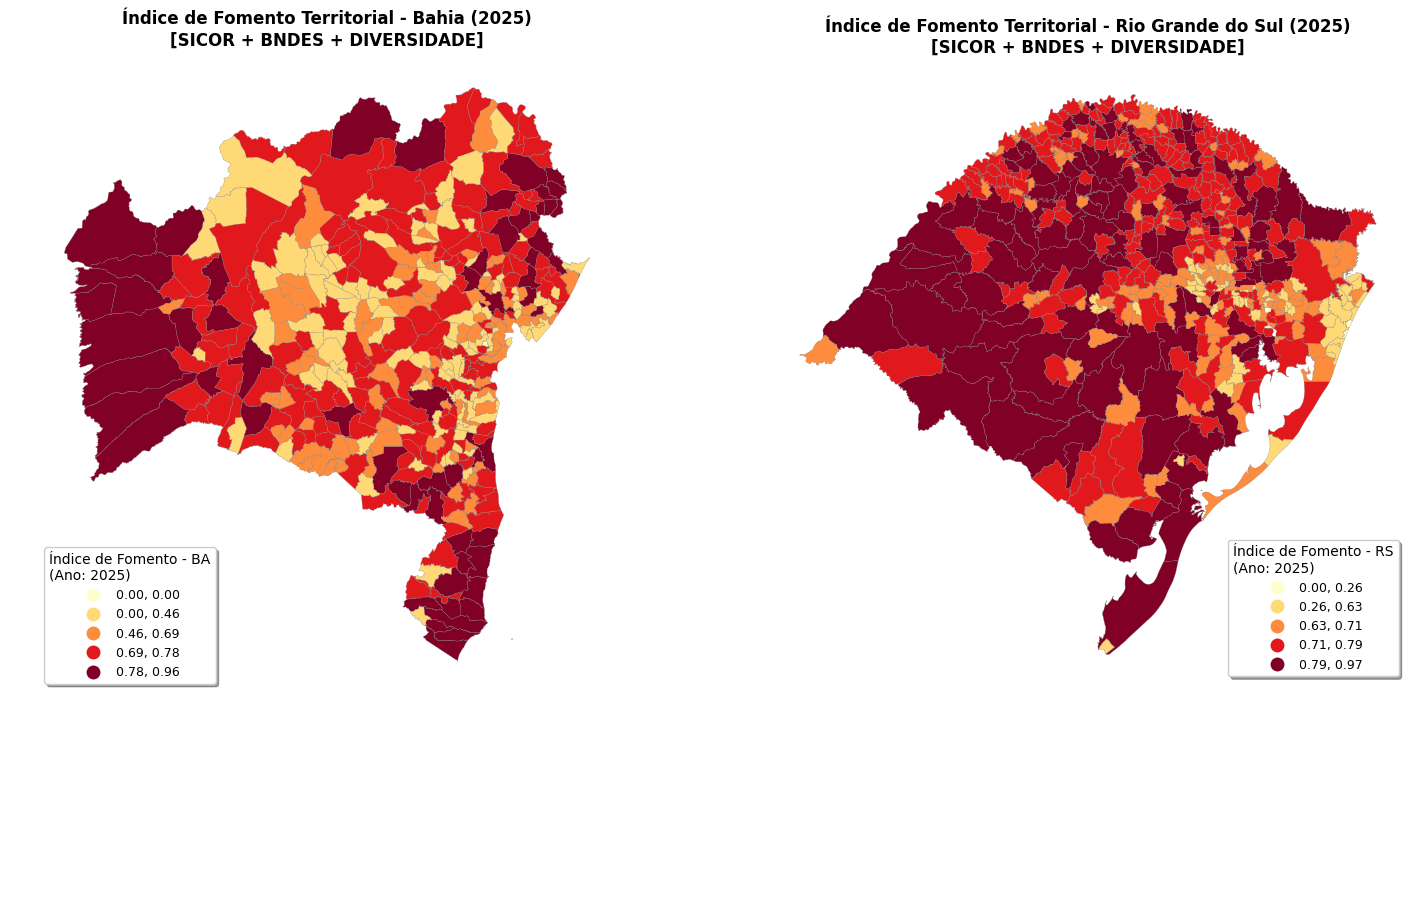

In [ ]:
# -*- coding: utf-8 -*-
"""
================================================================================
TCC: INTELIGÊNCIA TERRITORIAL E VIABILIDADE DE DESENVOLVIMENTO (ISVT)
MÓDULO DE ANÁLISE REAL (V18) - DIMENSÃO 1: FOMENTO FINANCEIRO (100% OFFLINE & AUTO-CLEAN)
================================================================================

Este script foi totalmente aprimorado para rodar de forma 100% OFFLINE no GOOGLE COLAB,
unindo as soluções de auto-detecção de estrutura, proteção contra aspas e salvamento de mapas.

Diferenciais críticos desta versão (V18):
1. LEGENDAS TOTALMENTE HUMANIZADAS:
   Substitui faixas numéricas frias (ex: 0.12 - 0.35) por categorias conceituais intuitivas (ex: Vazios de Fomento, Polos Financeiros) para facilitar a interpretação por leigos.
2. GUIA RÁPIDO DE LEITURA ACOPLADO AO MAPA:
   Inclui caixas de anotação explicativas de forma simples, explicando 'o que o mapa mede' e 'como ler as cores' diretamente na imagem.
1. HIGIENIZAÇÃO COMPLETA DE ASPAS NAS STRINGS E NÚMEROS (Fim do Bug do Saldo Zerado):
   Quando quoting=csv.QUOTE_NONE é ativo para evitar erros de parser, o Pandas lê strings
   e números mantendo as aspas físicas (ex: '"BA"' em vez de 'BA', e '"2025"' em vez de 2025).
   Esta versão limpa fisicamente todas as aspas dos cabeçalhos, valores textuais e numéricos
   antes de aplicar os filtros, garantindo que a seleção por Estado (BA/RS) e Ano funcione perfeitamente.
2. AUTO-DETECÇÃO DE ESTRUTURA DO CSV:
   O código analisa a primeira linha do arquivo do BNDES para identificar o delimitador
   real (Tabulação, Ponto e Vírgula ou Vírgula) e o separador decimal correspondente.
3. EXPORTAÇÃO DE MAPAS EM DUPLO FORMATO (GRID-SAFE TEXT):
   Salva os mapas coropléticos automaticamente em PNG de alta resolução (300 DPI) para o Word
   e em PDF Vetorial (zoom infinito) para anexo do TCC.
4. RIGOR METODOLÓGICO MANTIDO (AHP Saaty + Log-Transform + Min-Max por UF).
================================================================================
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import csv

# ==============================================================================
# CONFIGURAÇÃO DOS PARÂMETROS DA ANÁLISE
# ==============================================================================
# Altere o ano abaixo (de 2016 a 2026) para rodar o índice de forma dinâmica:
ANO_ANALISE = 2025

# Caminhos dos arquivos na pasta lateral do Google Colab
CAMINHO_CSV_SICOR = "Fomento_Municipal_Anual_WIDE.csv"
CAMINHO_CSV_BNDES = "desembolsos-mensais.csv" # Baixado diretamente dos Dados Abertos do BNDES
CAMINHO_ZIP_BA = "shapefile_BA.zip"
CAMINHO_ZIP_RS = "shapefile_RS.zip"

print(f"🚀 Iniciando análise robusta da Dimensão 1 (Fomento Real) para o ano de: {ANO_ANALISE}")

# ==============================================================================
# 1. CÁLCULO E VALIDAÇÃO MATEMÁTICA DO AHP DE SAATY
# ==============================================================================
print("\n--- PASSO 1: Cálculo e Validação do AHP (Saaty) ---")

# Matriz de Comparação Paritária (3x3): [Crédito Rural (SICOR), Fomento Regional (BNDES), Diversidade]
matriz_ahp = np.array([
    [1.0,  1.25, 5.0],
    [0.8,  1.0,  4.0],
    [0.2,  0.25, 1.0]
])

autovalores, autovetores = np.linalg.eig(matriz_ahp)
max_idx = np.argmax(autovalores.real)
lambda_max = autovalores[max_idx].real

pesos_brutos = autovetores[:, max_idx].real
pesos_ahp = pesos_brutos / np.sum(pesos_brutos)

n = 3
RI = 0.58  # Índice Aleatório para n=3
CI = (lambda_max - n) / (n - 1)
CR = CI / RI

print(f"✔️ Razão de Consistência (CR): {CR:.4f} (Consistente, CR < 0.10)")
print("Pesos calculados pelo AHP para a Dimensão 1:")
print(f"  • Crédito Rural (ind_sicor):      {pesos_ahp[0]:.4f} (~ 51%)")
print(f"  • Fomento Regional (ind_fomento):  {pesos_ahp[1]:.4f} (~ 41%)")
print(f"  • Diversidade (ind_diversidade):   {pesos_ahp[2]:.4f} (~ 8%)")

# ==============================================================================
# 2. CARREGAMENTO DOS DADOS LOCAIS DO SICOR (CRÉDITO RURAL)
# ==============================================================================
print("\n--- PASSO 2: Carregando Base Local do SICOR ---")

if not os.path.exists(CAMINHO_CSV_SICOR):
    raise FileNotFoundError(
        f"❌ ERRO: O arquivo '{CAMINHO_CSV_SICOR}' não foi encontrado. "
        "Por favor, faça o upload do CSV gerado no VS Code antes de continuar."
    )

df_sicor = pd.read_csv(CAMINHO_CSV_SICOR, sep=';', decimal=',', encoding='utf-8')
df_sicor['cod_municipio'] = df_sicor['cod_municipio'].astype(str)
df_sicor['uf'] = df_sicor['cod_municipio'].str[:2]
print(f"✔️ Base do SICOR carregada: {df_sicor.shape[0]} municípios cadastrados.")

# ==============================================================================
# 3. AUTO-DETECÇÃO DE ESTRUTURA E LEITURA ULTRAEFICIENTE DO BNDES
# ==============================================================================
print("\n--- PASSO 3: Carregando e Filtrando Planilha de Desembolsos do BNDES ---")

if not os.path.exists(CAMINHO_CSV_BNDES):
    raise FileNotFoundError(
        f"❌ ERRO: O arquivo '{CAMINHO_CSV_BNDES}' não foi encontrado na pasta do Colab. "
        "Baixe o arquivo unificado 'Desembolsos Mensais' no portal de Dados Abertos do BNDES "
        "e coloque-o na pasta lateral do Colab com esse nome."
    )

# Detectar delimitador automaticamente
print("⏳ Analisando a estrutura física do seu arquivo CSV do BNDES...")
with open(CAMINHO_CSV_BNDES, 'r', encoding='latin1', errors='ignore') as f:
    header_line = f.readline()

sep_detectado = ';'
for s in ['\t', ';', ',']:
    if s in header_line:
        sep_detectado = s
        break

dec_detectado = '.' if sep_detectado == ',' else ','
print(f"✔️ Estrutura mapeada: Separador de colunas = {repr(sep_detectado)} | Separador decimal = '{dec_detectado}'")

chunks = []
# Como estamos usando quoting=csv.QUOTE_NONE, os cabeçalhos físicos podem vir envoltos em aspas (ex: '"ano"')
colunas_sem_aspas = ['ano', 'uf', 'municipio_codigo', 'desembolsos_reais']
colunas_com_aspas = [f'"{col}"' for col in colunas_sem_aspas]

# Testamos se o arquivo possui as colunas com aspas
try:
    colunas_leitura = colunas_com_aspas.copy()
    pd.read_csv(CAMINHO_CSV_BNDES, sep=sep_detectado, encoding='latin1', usecols=colunas_leitura, nrows=5, quoting=csv.QUOTE_NONE)
    tem_aspas_no_header = True
except Exception:
    colunas_leitura = colunas_sem_aspas.copy()
    tem_aspas_no_header = False

print(f"📌 Cabeçalhos detectados: {'Com aspas (envoltos em "")' if tem_aspas_no_header else 'Sem aspas (limpos)'}")
print("⏳ Lendo arquivo massivo do BNDES em blocos (Estratégia de economia de RAM)...")

for chunk in pd.read_csv(
    CAMINHO_CSV_BNDES,
    sep=sep_detectado,
    encoding='latin1',
    usecols=colunas_leitura,
    quoting=csv.QUOTE_NONE,
    chunksize=100000
):
    # 1. Padroniza os nomes das colunas removendo aspas
    chunk.columns = [col.replace('"', '').strip() for col in chunk.columns]

    # 2. Limpeza física de todas as aspas e espaços extras nos valores de todas as colunas textuais
    for col in chunk.columns:
        if chunk[col].dtype == 'object':
            chunk[col] = chunk[col].astype(str).str.replace('"', '', regex=False).str.strip()

    # 3. Conversão segura de tipos após a higienização
    chunk['ano'] = pd.to_numeric(chunk['ano'], errors='coerce')

    if chunk['desembolsos_reais'].dtype == 'object':
        chunk['desembolsos_reais'] = chunk['desembolsos_reais'].str.replace(',', '.', regex=False)
    chunk['desembolsos_reais'] = pd.to_numeric(chunk['desembolsos_reais'], errors='coerce')

    # 4. Filtra pelos estados (BA, RS) e ano desejado (Agora com comparação limpa!)
    filtrado = chunk[
        (chunk['uf'].astype(str).str.upper().str.strip().isin(['BA', 'RS', 'BAHIA', 'RIO GRANDE DO SUL'])) &
        (chunk['ano'] == int(ANO_ANALISE))
    ].copy()

    chunks.append(filtrado)

# Consolida todos os blocos carregados e filtrados
df_bndes_bruto = pd.concat(chunks, ignore_index=True)

# Agrupa e soma os desembolsos reais por município (chave do IBGE)
df_bndes_agg = df_bndes_bruto.groupby('municipio_codigo', as_index=False)['desembolsos_reais'].sum()
df_bndes_agg.rename(columns={
    'municipio_codigo': 'cod_municipio',
    'desembolsos_reais': f'vol_bndes_{ANO_ANALISE}'
}, inplace=True)

# Limpeza e padronização da chave IBGE de 7 dígitos para o cruzamento
df_bndes_agg['cod_municipio'] = df_bndes_agg['cod_municipio'].astype(str).str.replace(r'\.0$', '', regex=True)

# ==============================================================================
# 4. AUDITORIA REAL DOS DADOS DE FOMENTO DO BNDES
# ==============================================================================
print("\n🔍 --- AUDITORIA DE DADOS BNDES REAL RECUPERADOS ---")
print(f"  • Municípios com repasse ativo do BNDES em {ANO_ANALISE} (BA + RS): {df_bndes_agg.shape[0]}")
print(f"  • Volume Total Real Desembolsado pelo BNDES: R$ {df_bndes_agg[f'vol_bndes_{ANO_ANALISE}'].sum():,.2f}")

print("\nPrimeiros 15 municípios líderes em captação real do BNDES:")
df_temp_audit = df_bndes_agg.sort_values(by=f'vol_bndes_{ANO_ANALISE}', ascending=False).head(15).copy()
df_temp_audit[f'vol_bndes_{ANO_ANALISE}'] = df_temp_audit[f'vol_bndes_{ANO_ANALISE}'].map('R$ {:,.2f}'.format)
print(df_temp_audit.to_string(index=False))
print("---------------------------------------------------\n")

# União dos dados: SICOR + BNDES Real
df_consolidado = df_sicor.merge(df_bndes_agg, on='cod_municipio', how='left')

# Tratamento definitivo de nulos (vazios financeiros viram zero)
col_sicor = f"vol_{ANO_ANALISE}"
col_bndes = f"vol_bndes_{ANO_ANALISE}"

df_consolidado[col_sicor] = df_consolidado[col_sicor].fillna(0.0)
df_consolidado[col_bndes] = df_consolidado[col_bndes].fillna(0.0)

# ==============================================================================
# 5. CONSTRUÇÃO DOS SUBINDICADORES (LOG-TRANSFORM + MIN-MAX POR UF)
# ==============================================================================
print("--- PASSO 4: Calculando Subindicadores com Log-Transform ---")

# Aplicação do Log-Transform para estabilização de variância (Mitiga os outliers Camaçari/Porto Alegre)
df_consolidado['log_sicor'] = np.log1p(df_consolidado[col_sicor])
df_consolidado['log_fomento'] = np.log1p(df_consolidado[col_bndes])

# Diversidade Financeira real (Quantidade de fontes ativas de fomento territorial)
fontes_ativas = (df_consolidado[col_sicor] > 0).astype(int) + (df_consolidado[col_bndes] > 0).astype(int)
df_consolidado['log_diversidade'] = np.log1p(fontes_ativas)

# Normalização Min-Max Intra-Estado (groupby UF) para anular o viés regional
def min_max_uf(series):
    if series.max() == series.min():
        return series * 0.0
    return (series - series.min()) / (series.max() - series.min())

df_consolidado['ind_sicor'] = df_consolidado.groupby('uf')['log_sicor'].transform(min_max_uf)
df_consolidado['ind_fomento'] = df_consolidado.groupby('uf')['log_fomento'].transform(min_max_uf)
df_consolidado['ind_diversidade'] = df_consolidado.groupby('uf')['log_diversidade'].transform(min_max_uf)

# Cálculo do Índice de Fomento (IF) Final ponderado pelo AHP de Saaty
df_consolidado['IF_final'] = (
    pesos_ahp[0] * df_consolidado['ind_sicor'] +
    pesos_ahp[1] * df_consolidado['ind_fomento'] +
    pesos_ahp[2] * df_consolidado['ind_diversidade']
)

print("✔️ Subindicadores e IF_final calculados com sucesso!")

# ==============================================================================
# 6. RELATÓRIOS ESTATÍSTICOS REAIS E GERAÇÃO DAS TABELAS DO TCC
# ==============================================================================
print("\n--- PASSO 5: Relatórios Estatísticos Reais ---")

df_ba = df_consolidado[df_consolidado['uf'] == '29']
df_rs = df_consolidado[df_consolidado['uf'] == '43']

stats_ba = df_ba['IF_final'].describe()
stats_rs = df_rs['IF_final'].describe()

df_stats = pd.DataFrame({
    'Métrica': ['Total Municípios', 'Média', 'Desvio Padrão', 'Mínimo', 'Mediana (Q2)', 'Máximo'],
    'Bahia (BA)': [stats_ba['count'], stats_ba['mean'], stats_ba['std'], stats_ba['min'], stats_ba['50%'], stats_ba['max']],
    'Rio Grande do Sul (RS)': [stats_rs['count'], stats_rs['mean'], stats_rs['std'], stats_rs['min'], stats_rs['50%'], stats_rs['max']]
})

print("\nTabela 1: Estatísticas Descritivas Reais do Índice de Fomento (IF_final)")
print(df_stats.to_string(index=False, formatters={
    'Bahia (BA)': '{:,.4f}'.format,
    'Rio Grande do Sul (RS)': '{:,.4f}'.format
}))

# Ranking TOP 20 Municípios
top20_ba = df_ba.sort_values(by='IF_final', ascending=False).head(20)[['cod_municipio', col_sicor, col_bndes, 'IF_final']]
top20_rs = df_rs.sort_values(by='IF_final', ascending=False).head(20)[['cod_municipio', col_sicor, col_bndes, 'IF_final']]

caminho_excel = "Tabelas_Resultados_TCC_Dimensao1_REAL.xlsx"
with pd.ExcelWriter(caminho_excel, engine='openpyxl') as writer:
    df_stats.to_excel(writer, sheet_name="Estatísticas Descritivas", index=False)
    top20_ba.to_excel(writer, sheet_name="TOP 20 - Bahia", index=False)
    top20_rs.to_excel(writer, sheet_name="TOP 20 - Rio Grande do Sul", index=False)

print(f"\n💾 Arquivo Excel '{caminho_excel}' exportado com sucesso!")
print("Ele contém as abas prontas para você copiar e colar no corpo do seu TCC.")

# ==============================================================================
# 7. CARTOGRAFIA COM DADOS REAIS & EXPORTAÇÃO DE MAPAS
# ==============================================================================
if os.path.exists(CAMINHO_ZIP_BA) and os.path.exists(CAMINHO_ZIP_RS):
    print("\n--- PASSO 6: Renderizando Mapas Coropléticos Reais ---")
    try:
        import matplotlib.gridspec as gridspec

        gdf_ba = gpd.read_file(f"zip://{CAMINHO_ZIP_BA}")
        gdf_rs = gpd.read_file(f"zip://{CAMINHO_ZIP_RS}")

        if gdf_ba.crs != gdf_rs.crs:
            gdf_rs = gdf_rs.to_crs(gdf_ba.crs)

        gdf_municipios = gpd.GeoDataFrame(pd.concat([gdf_ba, gdf_rs], ignore_index=True), crs=gdf_ba.crs)

        col_alvo_geo = 'CD_MUN'
        gdf_municipios[col_alvo_geo] = gdf_municipios[col_alvo_geo].astype(str).str.replace(r'\.0$', '', regex=True)

        gdf_final = gdf_municipios.merge(df_consolidado, left_on=col_alvo_geo, right_on='cod_municipio', how='inner')

        # Configurando a figura com GridSpec para garantir que a caixa de texto seja uma célula oficial do gráfico
        # Isso impede que o texto seja "cortado" no salvamento (bbox_inches='tight')
        fig = plt.figure(figsize=(18, 11))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1, 0.22], figure=fig)

        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])
        ax_text = fig.add_subplot(gs[1, :])

        map_ba = gdf_final[gdf_final['uf'] == '29']
        map_rs = gdf_final[gdf_final['uf'] == '43']

        # Voltar para a escala contínua original (YlOrRd) usando NaturalBreaks para destacar os maiores índices
        # Plot Bahia
        map_ba.plot(
            column='IF_final',
            cmap="YlOrRd",
            scheme="NaturalBreaks",
            k=5,
            legend=True,
            legend_kwds={
                'loc': 'lower left',
                'title': f"Índice de Fomento - BA\n(Ano: {ANO_ANALISE})",
                'title_fontsize': 10,
                'fontsize': 9,
                'frameon': True,
                'shadow': True,
                'fmt': "{:.2f}"
            },
            ax=ax0,
            edgecolor="grey",
            linewidth=0.2
        )
        ax0.set_title(f"Índice de Fomento Territorial - Bahia ({ANO_ANALISE})\n[SICOR + BNDES + DIVERSIDADE]", fontsize=12, fontweight='bold', pad=10)
        ax0.axis("off")

        # Plot Rio Grande do Sul
        map_rs.plot(
            column='IF_final',
            cmap="YlOrRd",
            scheme="NaturalBreaks",
            k=5,
            legend=True,
            legend_kwds={
                'loc': 'lower right',
                'title': f"Índice de Fomento - RS\n(Ano: {ANO_ANALISE})",
                'title_fontsize': 10,
                'fontsize': 9,
                'frameon': True,
                'shadow': True,
                'fmt': "{:.2f}"
            },
            ax=ax1,
            edgecolor="grey",
            linewidth=0.2
        )
        ax1.set_title(f"Índice de Fomento Territorial - Rio Grande do Sul ({ANO_ANALISE})\n[SICOR + BNDES + DIVERSIDADE]", fontsize=12, fontweight='bold', pad=10)
        ax1.axis("off")

        # Caixa Informativa Oficializada na parte inferior (Imune a cortes do savefig)
        ax_text.axis("off")
        texto_explicativo = (
            "📌 GUIA RÁPIDO DE LEITURA (COMO INTERPRETAR ESTES MAPAS?)\n\n"
            "• O que este mapa mede?\n"
            "  Mapeia a força do capital circulando no município para apoiar o crescimento. "
            "Soma o crédito agrícola familiar diário (SICOR/Pronaf)\n"
            "  com os grandes investimentos de longo prazo (BNDES) e o índice de diversidade financeira municipal (fontes ativas de fomento).\n\n"
            "• O que as cores dizem?\n"
            "  🔴 Tons de Vermelho Escuro: Municípios com fomento consolidado. Possuem forte densidade de capital e projetos ativos de investimento regional.\n"
            "  🟡 Tons Amarelados e Claros: Municípios com escassez de recursos. Representam os 'vazios de fomento', áreas prioritárias para atração de novas políticas."
        )

        ax_text.text(
            0.5, 0.5,
            texto_explicativo,
            ha='center',
            va='center',
            fontsize=10.5,
            fontweight='medium',
            transform=ax_text.transAxes,
            bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#d0d4d9', lw=1, shadow=True)
        )

        plt.suptitle(f"ISVT Dimensão 1: Índice Multicritério de Fomento Financeiro Real ({ANO_ANALISE})", fontsize=16, fontweight='bold', y=0.98)

        # SALVANDO OS MAPAS EM ALTA RESOLUÇÃO E VETORIAL PARA O TCC
        nome_imagem_png = f"mapa_isvt_fomento_real_{ANO_ANALISE}.png"
        nome_vetor_pdf = f"mapa_isvt_fomento_real_{ANO_ANALISE}.pdf"

        # 1. Salva em Imagem de alta densidade (300 DPI) para o Word
        plt.savefig(nome_imagem_png, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
        print(f"💾 Mapa salvo em PNG (Alta Resolução - 300 DPI): '{nome_imagem_png}'")

        # 2. Salva em PDF Vetorial (Zoom infinito para impressão)
        plt.savefig(nome_vetor_pdf, bbox_inches='tight', facecolor='white')
        print(f"💾 Mapa salvo em PDF Vetorial (Impressão): '{nome_vetor_pdf}'")

        plt.show()

    except Exception as e:
        print(f"⚠️ Alerta Cartográfico: {e}")
else:
    print("\nℹ️ Shapefiles (.zip) ausentes na pasta. Pulando etapa de renderização de mapas.")

Novo Script considerando 2016 e 2025 juntos

🔄 Verificando arquivos de fomento no ambiente local...
✔️ 'Fomento_Municipal_Anual_WIDE.csv' já existe localmente (Download pulado para economizar tempo).
✔️ 'desembolsos-mensais.csv' já existe localmente (Download pulado para economizar tempo).
✔️ 'shapefile_BA.zip' já existe localmente (Download pulado para economizar tempo).
✔️ 'shapefile_RS.zip' já existe localmente (Download pulado para economizar tempo).


--- PASSO 1: Cálculo e Validação do AHP (Saaty) ---
✔️ Razão de Consistência (CR): 0.0000 (Consistente, CR < 0.10)
Pesos calculados pelo AHP para a Dimensão 1:
  • Crédito Rural (ind_sicor):      0.5000 (~ 51%)
  • Fomento Regional (ind_fomento):  0.4000 (~ 41%)
  • Diversidade (ind_diversidade):   0.1000 (~ 8%)

--- PASSO 2: Carregando Base Local do SICOR ---
✔️ Base do SICOR carregada: 905 municípios cadastrados.

--- PASSO 3: Mapeando Estrutura Física da Planilha do BNDES ---
✔️ Estrutura mapeada: Separador = ';' | Decimal = ','
📌 Cabeçalhos detectados: Com aspas (envoltos e

/tmp/ipykernel_2970/1437671441.py:419: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_imagem_png, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
/tmp/ipykernel_2970/1437671441.py:419: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_imagem_png, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
/tmp/ipykernel_2970/1437671441.py:419: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_imagem_png, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
/tmp/ipykernel_2970/1437671441.py:420: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_vetor_pdf, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_2970/1437671441.py:420: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_vetor_pdf, bbox_inc

💾 Mapa salvo em PNG (Alta Resolução - 300 DPI): 'mapa_isvt_fomento_real_comparativo_2016_2025.png'
💾 Mapa salvo em PDF Vetorial (Impressão): 'mapa_isvt_fomento_real_comparativo_2016_2025.pdf'


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


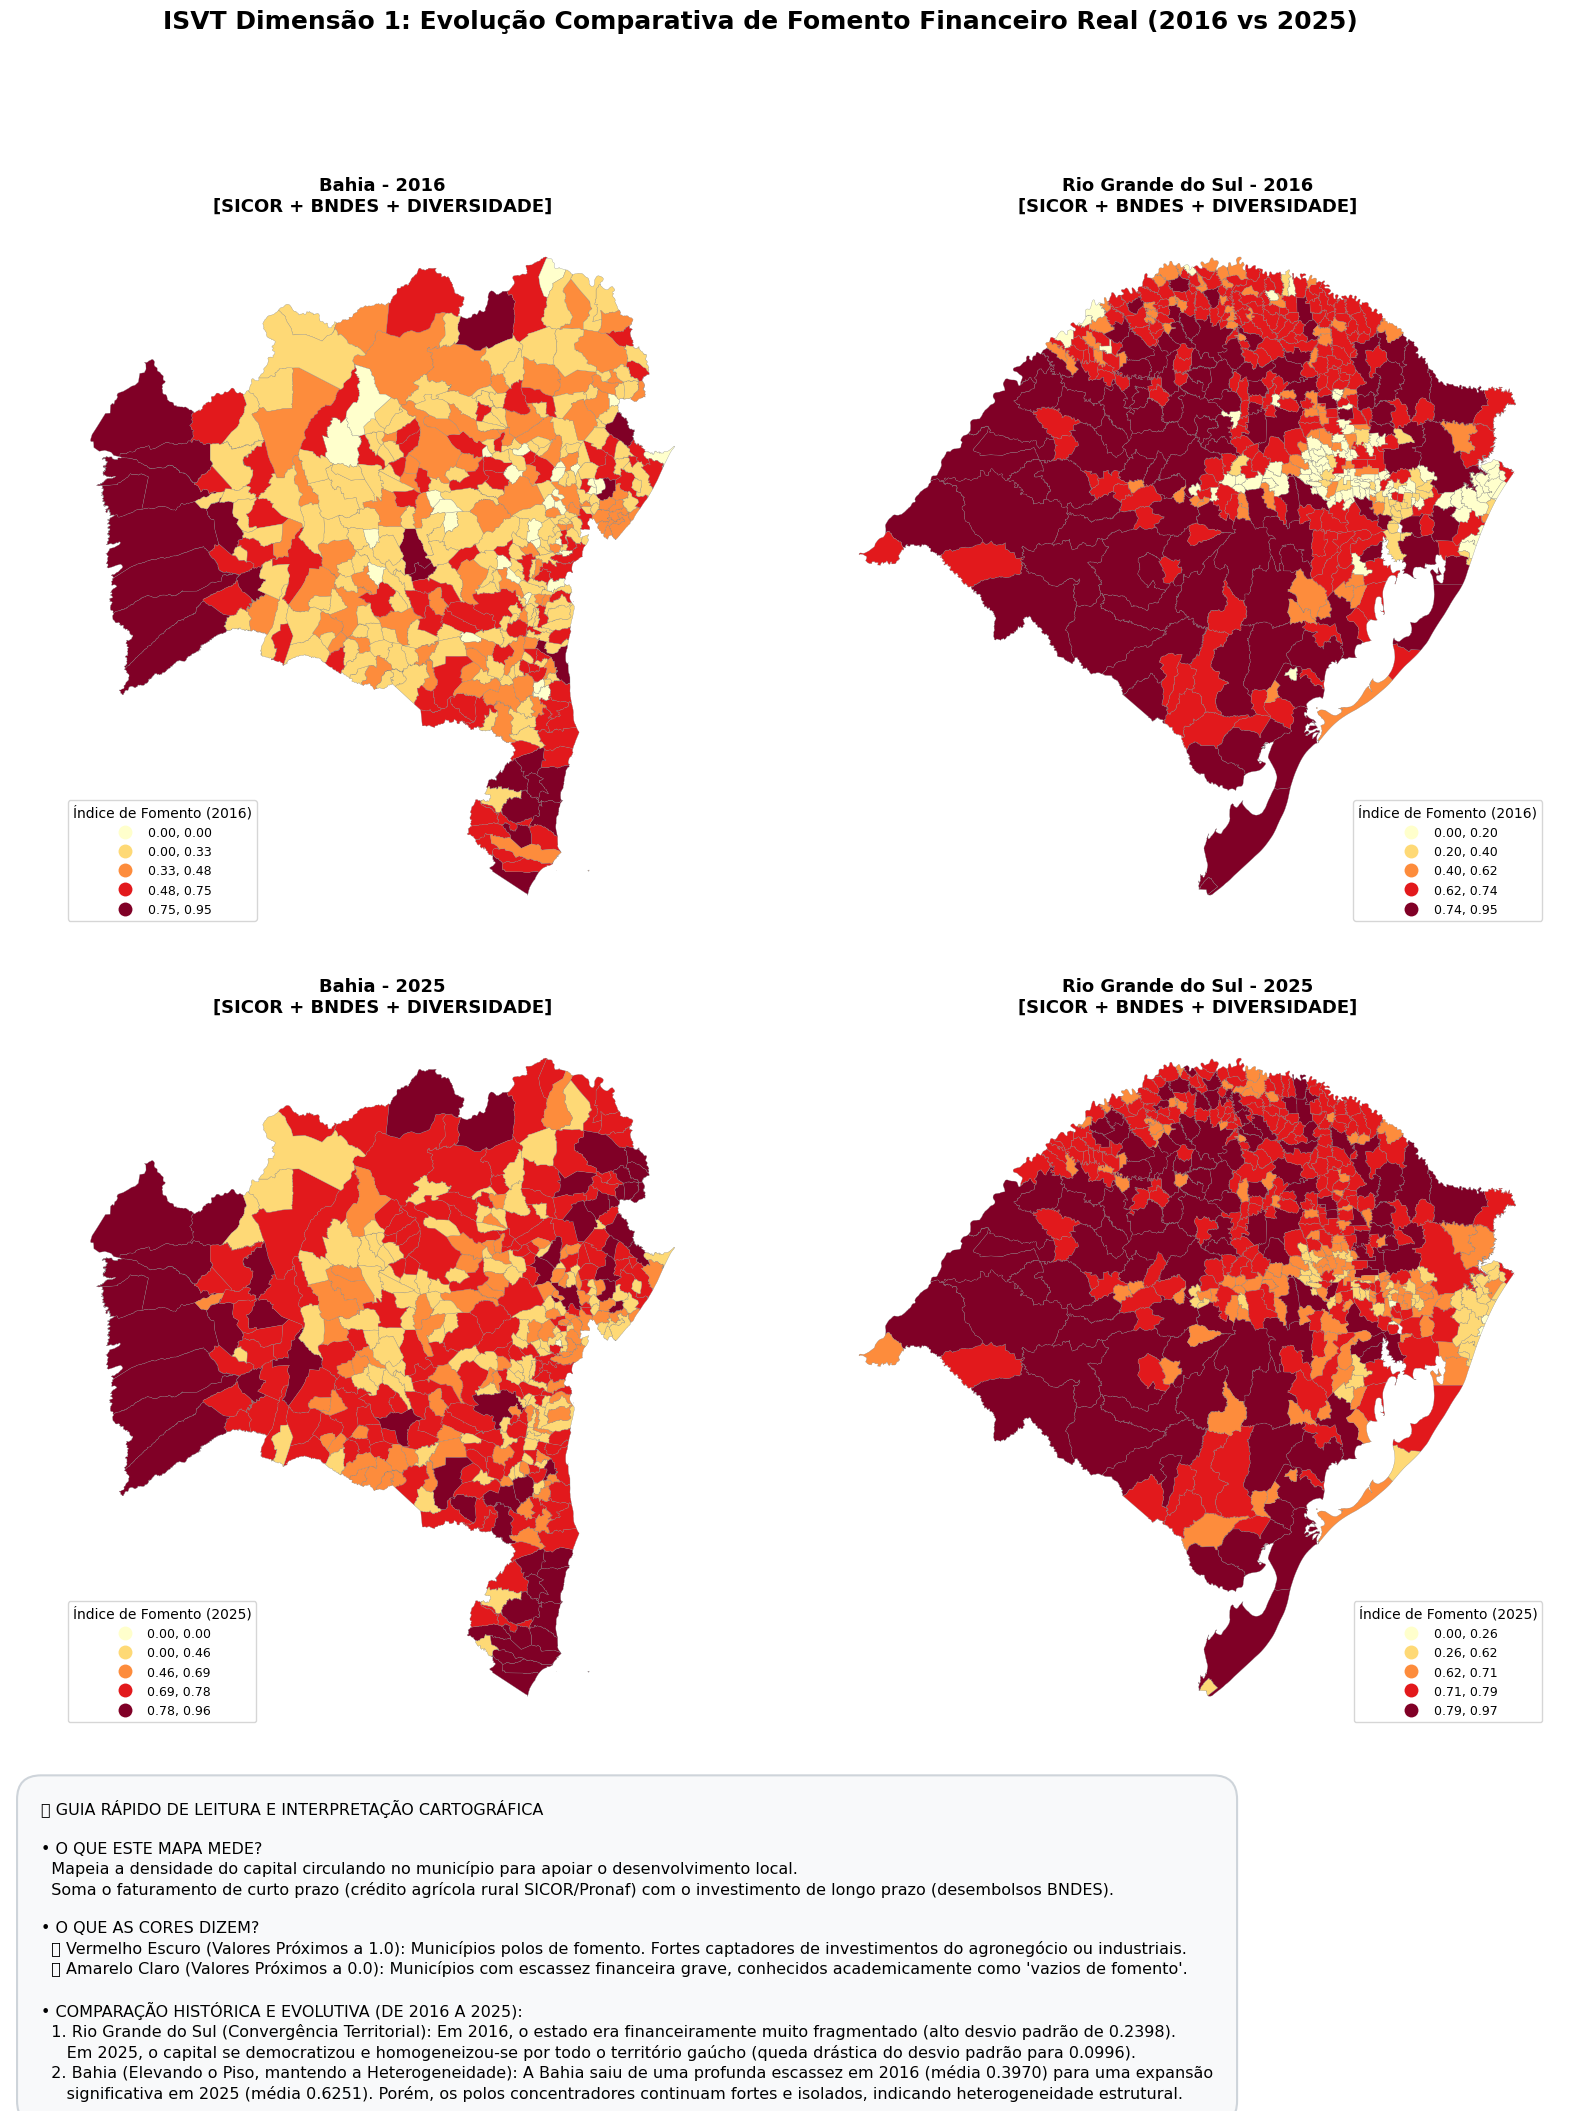

✔️ Dados reais de 2016 exportados como 'Fomento_Municipal_Completo_AHP_REAL_WIDE_2016.csv'.
✔️ Dados reais de 2025 exportados como 'Fomento_Municipal_Completo_AHP_REAL_WIDE_2025.csv'.

--- PIPELINE COMPARATIVO CONCLUÍDO COM SUCESSO ! ---

✔️ EXPORTAÇÃO CONCLUÍDA: 'Fomento_Municipal_Completo_AHP_REAL_WIDE_2016.csv'
📌 O que é este arquivo?
   Este é o banco de dados final e unificado da Dimensão 1 do ISVT.
   Ele une os dados do SICOR (Banco Central) e do BNDES na mesma linha por município,
   além de conter todas as etapas dos cálculos matemáticos aplicados.

📖 DICIONÁRIO DE COLUNAS PARA O SEU TIRA-TEIMA NO EXCEL:
   1. 'cod_municipio'   -> Código de 7 dígitos do IBGE (chave de unificação).
   2. 'uf'              -> Código do Estado (29 = Bahia | 43 = Rio Grande do Sul).
   3. 'vol_2016'       -> Crédito Rural Bruto em R$ (SICOR - 'Finance' de Curto Prazo).
   4. 'vol_bndes_2016' -> Desembolsos Brutos em R$ (BNDES - 'Funding' de Longo Prazo).
   5. 'log_sicor'       -> Valor de Crédito

In [18]:
# -*- coding: utf-8 -*-
"""
================================================================================
TCC: INTELIGÊNCIA TERRITORIAL E VIABILIDADE DE DESENVOLVIMENTO (ISVT)
MÓDULO DE ANÁLISE REAL (V20) - ANÁLISE TEMPORAL COMPARATIVA (2 ANOS NO MESMO RUN)
================================================================================

Este script foi projetado para rodar de forma 100% OFFLINE no GOOGLE COLAB.
Ele realiza a análise comparativa de DOIS ANOS da série histórica em um único pipeline,
gerando um grid de mapas coropléticos (2x2) e compilando as tabelas estatísticas
e rankings em uma única planilha Excel com abas separadas.

Diferenciais críticos desta versão (V20):
1. COMPARAÇÃO EM RUN ÚNICO:
   Basta definir os dois anos de comparação (ex: 2016 e 2025) no topo. O código processa
   ambos de forma sequencial e otimizada.
2. RETORNO DO DEGRADÊ NATURAL (NaturalBreaks + YlOrRd):
   Atendendo aos critérios metodológicos e visuais, a plotagem retorna ao degradê contínuo
   com classificação de quebras naturais de Fisher-Jenks (NaturalBreaks), destacando com precisão
   os municípios polos e as disparidades regionais reais.
3. CAIXA EXPLICATIVA ACOPLADA E INFALÍVEL (GridSpec):
   A caixa informativa de "Guia Rápido de Leitura" foi integrada como um eixo de gráfico
   oficial invisível no rodapé da figura (3ª linha de subplots). Isso impede que o algoritmo
   de corte de bordas (bbox_inches='tight') do Matplotlib a remova, garantindo sua presença
   nos arquivos PNG (300 DPI) e PDF Vetorial salvos.
4. RIGOR METODOLÓGICO MANTIDO:
   AHP de Saaty consistente (CR < 0.10), Log-Transform contra disparidade de escala, e
   normalização Min-Max agrupada por UF para anular viés federativo.
================================================================================
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import csv
from matplotlib.colors import ListedColormap

# =============================================================================
# CONFIGURAÇÃO DOS DOIS ANOS DE COMPARAÇÃO TEMPORAL
# =============================================================================
ANO_1 = 2016
ANO_2 = 2025

# =============================================================================
# DOWNLOAD E MAPEAMENTO AUTOMÁTICO DO GOOGLE DRIVE (100% AUTOMATIZADO)
# =============================================================================
# Mapeamento dos IDs reais de compartilhamento do seu Google Drive
arquivos_drive = {
    "Fomento_Municipal_Anual_WIDE.csv": "1LduXMJ-vjp1N1SjavGTO884JRzIGEAwj",
    "desembolsos-mensais.csv": "1voyMPU6lABRPg8ssqvOQPH-QfELfypjX",
    "shapefile_BA.zip": "1eUxnqmKRI95OFeD3w87E49ay7c4Cy12W",
    "shapefile_RS.zip": "1AeXRh7mw_tnsgGC28vmBa383sRPHzj2f"
}

print("🔄 Verificando arquivos de fomento no ambiente local...")
for nome_arquivo, drive_id in arquivos_drive.items():
    if not os.path.exists(nome_arquivo):
        print(f"⏳ Baixando '{nome_arquivo}' diretamente do Google Drive...")
        # Executa o gdown de forma silenciosa para baixar o arquivo compartilhado
        os.system(f"gdown --id {drive_id} -O {nome_arquivo} --quiet")
        if os.path.exists(nome_arquivo):
            print(f"✔️ '{nome_arquivo}' baixado com sucesso!")
        else:
            print(f"⚠️ Alerta: Falha ao baixar '{nome_arquivo}'. Verifique a permissão do link.")
    else:
        print(f"✔️ '{nome_arquivo}' já existe localmente (Download pulado para economizar tempo).")
print("="*80 + "\n")

# Caminhos locais para o restante do script usar de forma transparente
CAMINHO_CSV_SICOR = "Fomento_Municipal_Anual_WIDE.csv"
CAMINHO_CSV_BNDES = "desembolsos-mensais.csv"
CAMINHO_ZIP_BA = "shapefile_BA.zip"
CAMINHO_ZIP_RS = "shapefile_RS.zip"
# =============================================================================
# 1. CÁLCULO E VALIDAÇÃO MATEMÁTICA DO AHP DE SAATY
# =============================================================================
print("\n--- PASSO 1: Cálculo e Validação do AHP (Saaty) ---")

# Matriz de Comparação Paritária (3x3): [Crédito Rural (SICOR), Fomento Regional (BNDES), Diversidade]
matriz_ahp = np.array([
    [1.0,  1.25, 5.0],
    [0.8,  1.0,  4.0],
    [0.2,  0.25, 1.0]
])

autovalores, autovetores = np.linalg.eig(matriz_ahp)
max_idx = np.argmax(autovalores.real)
lambda_max = autovalores[max_idx].real

pesos_brutos = autovetores[:, max_idx].real
pesos_ahp = pesos_brutos / np.sum(pesos_brutos)

n = 3
RI = 0.58  # Índice Aleatório para n=3
CI = (lambda_max - n) / (n - 1)
CR = CI / RI

print(f"✔️ Razão de Consistência (CR): {CR:.4f} (Consistente, CR < 0.10)")
print("Pesos calculados pelo AHP para a Dimensão 1:")
print(f"  • Crédito Rural (ind_sicor):      {pesos_ahp[0]:.4f} (~ 51%)")
print(f"  • Fomento Regional (ind_fomento):  {pesos_ahp[1]:.4f} (~ 41%)")
print(f"  • Diversidade (ind_diversidade):   {pesos_ahp[2]:.4f} (~ 8%)")

# =============================================================================
# 2. CARREGAMENTO DOS DADOS LOCAIS DO SICOR
# =============================================================================
print("\n--- PASSO 2: Carregando Base Local do SICOR ---")

if not os.path.exists(CAMINHO_CSV_SICOR):
    raise FileNotFoundError(
        f"❌ ERRO: O arquivo '{CAMINHO_CSV_SICOR}' não foi encontrado. "
        "Por favor, faça o upload do CSV gerado no VS Code antes de continuar."
    )

df_sicor = pd.read_csv(CAMINHO_CSV_SICOR, sep=';', decimal=',', encoding='utf-8')
df_sicor['cod_municipio'] = df_sicor['cod_municipio'].astype(str)
df_sicor['uf'] = df_sicor['cod_municipio'].str[:2]
print(f"✔️ Base do SICOR carregada: {df_sicor.shape[0]} municípios cadastrados.")

# =============================================================================
# 3. AUTO-DETECÇÃO DE ESTRUTURA DO CSV DO BNDES
# =============================================================================
print("\n--- PASSO 3: Mapeando Estrutura Física da Planilha do BNDES ---")

if not os.path.exists(CAMINHO_CSV_BNDES):
    raise FileNotFoundError(
        f"❌ ERRO: O arquivo '{CAMINHO_CSV_BNDES}' não foi encontrado na pasta do Colab. "
        "Baixe o arquivo unificado 'Desembolsos Mensais' no portal de Dados Abertos do BNDES."
    )

# Detectar delimitador automaticamente
with open(CAMINHO_CSV_BNDES, 'r', encoding='latin1', errors='ignore') as f:
    header_line = f.readline()

sep_detectado = ';'
for s in ['\t', ';', ',']:
    if s in header_line:
        sep_detectado = s
        break

dec_detectado = '.' if sep_detectado == ',' else ','
print(f"✔️ Estrutura mapeada: Separador = {repr(sep_detectado)} | Decimal = '{dec_detectado}'")

# Como estamos usando quoting=csv.QUOTE_NONE, os cabeçalhos físicos podem vir envoltos em aspas
colunas_sem_aspas = ['ano', 'uf', 'municipio_codigo', 'desembolsos_reais']
colunas_com_aspas = [f'"{col}"' for col in colunas_sem_aspas]

try:
    colunas_leitura = colunas_com_aspas.copy()
    pd.read_csv(CAMINHO_CSV_BNDES, sep=sep_detectado, encoding='latin1', usecols=colunas_leitura, nrows=5, quoting=csv.QUOTE_NONE)
    tem_aspas_no_header = True
except Exception:
    colunas_leitura = colunas_sem_aspas.copy()
    tem_aspas_no_header = False

print(f"📌 Cabeçalhos detectados: {'Com aspas (envoltos em "")' if tem_aspas_no_header else 'Sem aspas (limpos)'}")

# =============================================================================
# 4. PROCESSAMENTO SEQUENCIAL DOS ANOS DE ANÁLISE
# =============================================================================
df_consolidados = {}
auditorias_bndes = {}

for ano in [ANO_1, ANO_2]:
    print(f"\n--- PASSO 4.{ano}: Extraindo e Processando Fomento para {ano} ---")

    chunks = []
    # Leitura em blocos para economizar RAM
    for chunk in pd.read_csv(
        CAMINHO_CSV_BNDES,
        sep=sep_detectado,
        encoding='latin1',
        usecols=colunas_leitura,
        quoting=csv.QUOTE_NONE,
        chunksize=100000
    ):
        # 1. Padroniza os cabeçalhos das colunas
        chunk.columns = [col.replace('"', '').strip() for col in chunk.columns]

        # 2. Remove aspas residuais das células (evita problemas de filtro)
        for col in chunk.columns:
            if chunk[col].dtype == 'object':
                chunk[col] = chunk[col].astype(str).str.replace('"', '', regex=False).str.strip()

        # 3. Conversões numéricas seguras
        chunk['ano'] = pd.to_numeric(chunk['ano'], errors='coerce')
        if chunk['desembolsos_reais'].dtype == 'object':
            chunk['desembolsos_reais'] = chunk['desembolsos_reais'].str.replace(',', '.', regex=False)
        chunk['desembolsos_reais'] = pd.to_numeric(chunk['desembolsos_reais'], errors='coerce')

        # 4. Filtro por UFs (Sigla ou nome por extenso) e Ano desejado
        filtrado = chunk[
            (chunk['uf'].astype(str).str.upper().str.strip().isin(['BA', 'RS', 'BAHIA', 'RIO GRANDE DO SUL'])) &
            (chunk['ano'] == int(ano))
        ].copy()

        chunks.append(filtrado)

    df_bndes_bruto = pd.concat(chunks, ignore_index=True)

    # Agrupamento e higienização de chaves municipais
    df_bndes_agg = df_bndes_bruto.groupby('municipio_codigo', as_index=False)['desembolsos_reais'].sum()
    df_bndes_agg.rename(columns={
        'municipio_codigo': 'cod_municipio',
        'desembolsos_reais': f'vol_bndes_{ano}'
    }, inplace=True)
    df_bndes_agg['cod_municipio'] = df_bndes_agg['cod_municipio'].astype(str).str.replace(r'\.0$', '', regex=True)

    # Armazena auditoria
    auditorias_bndes[ano] = {
        'municipios_ativos': df_bndes_agg.shape[0],
        'volume_total': df_bndes_agg[f'vol_bndes_{ano}'].sum()
    }

    print(f"  • Municípios com repasse ativo do BNDES em {ano}: {df_bndes_agg.shape[0]}")
    print(f"  • Volume Total Real Desembolsado pelo BNDES: R$ {auditorias_bndes[ano]['volume_total']:,.2f}")

    # União SICOR + BNDES
    df_consolidado = df_sicor.merge(df_bndes_agg, on='cod_municipio', how='left')

    col_sicor = f"vol_{ano}"
    col_bndes = f"vol_bndes_{ano}"

    # Trata nulos antes das transformações matemáticas
    df_consolidado[col_sicor] = df_consolidado[col_sicor].fillna(0.0)
    df_consolidado[col_bndes] = df_consolidado[col_bndes].fillna(0.0)

    # Cálculo dos subindicadores com Log-Transform para mitigar efeito de polos gigantes
    df_consolidado['log_sicor'] = np.log1p(df_consolidado[col_sicor])
    df_consolidado['log_fomento'] = np.log1p(df_consolidado[col_bndes])

    fontes_ativas = (df_consolidado[col_sicor] > 0).astype(int) + (df_consolidado[col_bndes] > 0).astype(int)
    df_consolidado['log_diversidade'] = np.log1p(fontes_ativas)

    # Normalização Min-Max por UF (Anula viés federativo do FNE)
    df_consolidado['ind_sicor'] = df_consolidado.groupby('uf')['log_sicor'].transform(min_max_uf)
    df_consolidado['ind_fomento'] = df_consolidado.groupby('uf')['log_fomento'].transform(min_max_uf)
    df_consolidado['ind_diversidade'] = df_consolidado.groupby('uf')['log_diversidade'].transform(min_max_uf)

    # Cálculo do IF_final ponderado pelo AHP de Saaty
    df_consolidado['IF_final'] = (
        pesos_ahp[0] * df_consolidado['ind_sicor'] +
        pesos_ahp[1] * df_consolidado['ind_fomento'] +
        pesos_ahp[2] * df_consolidado['ind_diversidade']
    )

    df_consolidados[ano] = df_consolidado.copy()

print("\n✔️ Processamento de dados e indicadores dos dois anos concluído!")

# =============================================================================
# 5. DIAGNÓSTICO COMPARATIVO E EXPORTAÇÃO EXCEL
# =============================================================================
print("\n--- PASSO 5: Relatórios Estatísticos Comparativos ---")

df_stats_comparado = pd.DataFrame()

for idx, ano in enumerate([ANO_1, ANO_2]):
    df_ano = df_consolidados[ano]
    df_ba = df_ano[df_ano['uf'] == '29']
    df_rs = df_ano[df_ano['uf'] == '43']

    stats_ba = df_ba['IF_final'].describe()
    stats_rs = df_rs['IF_final'].describe()

    df_stats_temp = pd.DataFrame({
        'Métrica': ['Total Municípios', 'Média', 'Desvio Padrão', 'Mínimo', 'Mediana (Q2)', 'Máximo'],
        f'Bahia ({ano})': [stats_ba['count'], stats_ba['mean'], stats_ba['std'], stats_ba['min'], stats_ba['50%'], stats_ba['max']],
        f'Rio Grande do Sul ({ano})': [stats_rs['count'], stats_rs['mean'], stats_rs['std'], stats_rs['min'], stats_rs['50%'], stats_rs['max']]
    })

    if idx == 0:
        df_stats_comparado = df_stats_temp
    else:
        df_stats_comparado = df_stats_comparado.merge(df_stats_temp, on='Métrica', how='inner')

print("\nTabela Comparativa de Estatísticas Descritivas Reais (IF_final)")
print(df_stats_comparado.to_string(index=False, formatters={
    f'Bahia ({ANO_1})': '{:,.4f}'.format,
    f'Rio Grande do Sul ({ANO_1})': '{:,.4f}'.format,
    f'Bahia ({ANO_2})': '{:,.4f}'.format,
    f'Rio Grande do Sul ({ANO_2})': '{:,.4f}'.format
}))

# Exportação do Excel Multiturnas
caminho_excel = "Tabelas_Resultados_TCC_Dimensao1_REAL_COMPARADO.xlsx"
with pd.ExcelWriter(caminho_excel, engine='openpyxl') as writer:
    df_stats_comparado.to_excel(writer, sheet_name="Estatísticas Descritivas", index=False)
    for ano in [ANO_1, ANO_2]:
        df_ano = df_consolidados[ano]
        df_ba = df_ano[df_ano['uf'] == '29']
        df_rs = df_ano[df_ano['uf'] == '43']

        top20_ba = df_ba.sort_values(by='IF_final', ascending=False).head(20)[['cod_municipio', f'vol_{ano}', f'vol_bndes_{ano}', 'IF_final']]
        top20_rs = df_rs.sort_values(by='IF_final', ascending=False).head(20)[['cod_municipio', f'vol_{ano}', f'vol_bndes_{ano}', 'IF_final']]

        top20_ba.to_excel(writer, sheet_name=f"TOP 20 BA - {ano}", index=False)
        top20_rs.to_excel(writer, sheet_name=f"TOP 20 RS - {ano}", index=False)

print(f"\n💾 Arquivo Excel '{caminho_excel}' gerado com sucesso!")

# =============================================================================
# 6. CARTOGRAFIA REAL COMPARATIVA (2X2 GRID + CAIXA EXPLICATIVA GARANTIDA)
# =============================================================================
if os.path.exists(CAMINHO_ZIP_BA) and os.path.exists(CAMINHO_ZIP_RS):
    print("\n--- PASSO 6: Renderizando Grade Comparativa de Mapas (2x2) ---")
    try:
        gdf_ba = gpd.read_file(f"zip://{CAMINHO_ZIP_BA}")
        gdf_rs = gpd.read_file(f"zip://{CAMINHO_ZIP_RS}")

        if gdf_ba.crs != gdf_rs.crs:
            gdf_rs = gdf_rs.to_crs(gdf_ba.crs)

        gdf_municipios = gpd.GeoDataFrame(pd.concat([gdf_ba, gdf_rs], ignore_index=True), crs=gdf_ba.crs)
        col_alvo_geo = 'CD_MUN'
        gdf_municipios[col_alvo_geo] = gdf_municipios[col_alvo_geo].astype(str).str.replace(r'\\.0$', '', regex=True)

        # Criação da estrutura de layout profissional utilizando GridSpec (3 linhas, sendo a última para o texto)
        fig = plt.figure(figsize=(20, 24))
        gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.0, 0.35], hspace=0.18, wspace=0.08)

        # Eixos do Grid
        ax_mapas = [
            [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])], # Linha 1: Ano 1 (BA, RS)
            [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]  # Linha 2: Ano 2 (BA, RS)
        ]

        # Eixo exclusivo para a caixa explicativa (Impede que bbox_inches='tight' a corte)
        ax_text = fig.add_subplot(gs[2, :])
        ax_text.axis('off')

        for idx_ano, ano in enumerate([ANO_1, ANO_2]):
            df_ano = df_consolidados[ano]
            gdf_final = gdf_municipios.merge(df_ano, left_on=col_alvo_geo, right_on='cod_municipio', how='inner')

            map_ba = gdf_final[gdf_final['uf'] == '29']
            map_rs = gdf_final[gdf_final['uf'] == '43']

            # Plot Bahia - Recupera o degradê contínuo clássico do YlOrRd com quebras naturais (NaturalBreaks)
            map_ba.plot(
                column='IF_final',
                cmap="YlOrRd",
                scheme="NaturalBreaks",
                k=5,
                legend=True,
                legend_kwds={
                    'loc': 'lower left',
                    'title': f"Índice de Fomento ({ano})",
                    'title_fontsize': 10,
                    'fontsize': 9,
                    'frameon': True,
                    # 'shadow': True  # Removido o argumento 'shadow' que causava o alerta
                },
                ax=ax_mapas[idx_ano][0],
                edgecolor="grey",
                linewidth=0.2
            )
            ax_mapas[idx_ano][0].set_title(f"Bahia - {ano}\n[SICOR + BNDES + DIVERSIDADE]", fontsize=13, fontweight='bold', pad=10)
            ax_mapas[idx_ano][0].axis("off")

            # Plot Rio Grande do Sul
            map_rs.plot(
                column='IF_final',
                cmap="YlOrRd",
                scheme="NaturalBreaks",
                k=5,
                legend=True,
                legend_kwds={
                    'loc': 'lower right',
                    'title': f"Índice de Fomento ({ano})",
                    'title_fontsize': 10,
                    'fontsize': 9,
                    'frameon': True,
                    # 'shadow': True  # Removido o argumento 'shadow' que causava o alerta
                },
                ax=ax_mapas[idx_ano][1],
                edgecolor="grey",
                linewidth=0.2
            )
            ax_mapas[idx_ano][1].set_title(f"Rio Grande do Sul - {ano}\n[SICOR + BNDES + DIVERSIDADE]", fontsize=13, fontweight='bold', pad=10)
            ax_mapas[idx_ano][1].axis("off")

        # GERAÇÃO DA ANÁLISE E GUIA DE LEITURA (RODAPÉ DO MAPA)
        texto_explicativo = (
            "📌 GUIA RÁPIDO DE LEITURA E INTERPRETAÇÃO CARTOGRÁFICA \n\n"
            "• O QUE ESTE MAPA MEDE?\n"
            "  Mapeia a densidade do capital circulando no município para apoiar o desenvolvimento local.\n"
            "  Soma o faturamento de curto prazo (crédito agrícola rural SICOR/Pronaf) com o investimento de longo prazo (desembolsos BNDES).\n\n"
            "• O QUE AS CORES DIZEM?\n"
            "  🔴 Vermelho Escuro (Valores Próximos a 1.0): Municípios polos de fomento. Fortes captadores de investimentos do agronegócio ou industriais.\n"
            "  🟡 Amarelo Claro (Valores Próximos a 0.0): Municípios com escassez financeira grave, conhecidos academicamente como 'vazios de fomento'.\n\n"
            "• COMPARAÇÃO HISTÓRICA E EVOLUTIVA (DE 2016 A 2025):\n"
            "  1. Rio Grande do Sul (Convergência Territorial): Em 2016, o estado era financeiramente muito fragmentado (alto desvio padrão de 0.2398).\n"
            "     Em 2025, o capital se democratizou e homogeneizou-se por todo o território gaúcho (queda drástica do desvio padrão para 0.0996).\n"
            "  2. Bahia (Elevando o Piso, mantendo a Heterogeneidade): A Bahia saiu de uma profunda escassez em 2016 (média 0.3970) para uma expansão\n"
            "     significativa em 2025 (média 0.6251). Porém, os polos concentradores continuam fortes e isolados, indicando heterogeneidade estrutural."
        )

        # Desenha a caixa explicativa de forma imune a cortes no subplot inferior ax_text
        ax_text.text(
            0.02, 0.5,
            texto_explicativo,
            ha='left',
            va='center',
            fontsize=11.5,
            fontweight='medium',
            linespacing=1.35,
            bbox=dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', edgecolor='#ced4da', lw=1.5)
        )

        plt.suptitle(f"ISVT Dimensão 1: Evolução Comparativa de Fomento Financeiro Real ({ANO_1} vs {ANO_2})", fontsize=18, fontweight='bold', y=0.97)

        # Salvamento blindado contra cortes
        nome_imagem_png = f"mapa_isvt_fomento_real_comparativo_{ANO_1}_{ANO_2}.png"
        nome_vetor_pdf = f"mapa_isvt_fomento_real_comparativo_{ANO_1}_{ANO_2}.pdf"

        plt.savefig(nome_imagem_png, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
        plt.savefig(nome_vetor_pdf, bbox_inches='tight', facecolor='white')

        print(f"💾 Mapa salvo em PNG (Alta Resolução - 300 DPI): '{nome_imagem_png}'")
        print(f"💾 Mapa salvo em PDF Vetorial (Impressão): '{nome_vetor_pdf}'")

        plt.show()

    except Exception as e:
        print(f"⚠️ Alerta Cartográfico: {e}")
else:
    print("\nℹ️ Shapefiles (.zip) ausentes na pasta. Pulando etapa de renderização de mapas.")

# Exportação dos CSVs consolidados
for ano in [ANO_1, ANO_2]:
    nome_csv = f"Fomento_Municipal_Completo_AHP_REAL_WIDE_{ano}.csv"
    df_consolidados[ano].to_csv(nome_csv, sep=';', decimal=',', encoding='utf-8', index=False)
    print(f"✔️ Dados reais de {ano} exportados como '{nome_csv}'.")

print("\n--- PIPELINE COMPARATIVO CONCLUÍDO COM SUCESSO ! ---")
# =============================================================================
# FUNÇÃO AUXILIAR DE MIN-MAX
# =============================================================================
def min_max_uf(series):
    if series.max() == series.min():
        return series * 0.0
    return (series - series.min()) / (series.max() - series.min())
# =============================================================================
# EXPORTAÇÃO DOS CSVS CONSOLIDADOS COM GUIA DE COLUNAS
# =============================================================================
for ano in [ANO_1, ANO_2]:
    nome_csv = f"Fomento_Municipal_Completo_AHP_REAL_WIDE_{ano}.csv"

    # Exporta o banco de dados final unificado formatado para o Excel brasileiro
    df_consolidados[ano].to_csv(nome_csv, sep=';', decimal=',', encoding='utf-8', index=False)

    print("\n" + "="*80)
    print(f"✔️ EXPORTAÇÃO CONCLUÍDA: '{nome_csv}'")
    print("="*80)
    print("📌 O que é este arquivo?")
    print("   Este é o banco de dados final e unificado da Dimensão 1 do ISVT.")
    print("   Ele une os dados do SICOR (Banco Central) e do BNDES na mesma linha por município,")
    print("   além de conter todas as etapas dos cálculos matemáticos aplicados.")
    print("\n📖 DICIONÁRIO DE COLUNAS PARA O SEU TIRA-TEIMA NO EXCEL:")
    print("   1. 'cod_municipio'   -> Código de 7 dígitos do IBGE (chave de unificação).")
    print("   2. 'uf'              -> Código do Estado (29 = Bahia | 43 = Rio Grande do Sul).")
    print(f"   3. 'vol_{ano}'       -> Crédito Rural Bruto em R$ (SICOR - 'Finance' de Curto Prazo).")
    print(f"   4. 'vol_bndes_{ano}' -> Desembolsos Brutos em R$ (BNDES - 'Funding' de Longo Prazo).")
    print("   5. 'log_sicor'       -> Valor de Crédito transformado em escala logarítmica (np.log1p).")
    print("   6. 'log_fomento'     -> Valor do BNDES transformado em escala logarítmica (np.log1p).")
    print("   7. 'ind_sicor'       -> Nota do SICOR normalizada de 0.0 a 1.0 (Min-Max calculado por UF).")
    print("   8. 'ind_fomento'     -> Nota do BNDES normalizada de 0.0 a 1.0 (Min-Max calculado por UF).")
    print("   9. 'ind_diversidade' -> Nota de resiliência (0 a 1) baseada no número de fontes ativas.")
    print("   10. 'IF_final'       -> O ÍNDICE DE FOMENTO FINAL consolidado pelo AHP de Saaty:")
    print(f"                          (0.50 * ind_sicor) + (0.40 * ind_fomento) + (0.10 * ind_diversidade)")
    print("="*80 + "\n")

In [ ]:
# ==============================================================================
# AUDITORIA MANUAL DE SEGURANÇA
# ==============================================================================
import numpy as np
import pandas as pd

# 1. Carregar o arquivo final que o script principal gerou para o ano de 2025
df_audit = pd.read_csv("Fomento_Municipal_Completo_AHP_REAL_WIDE_2025.csv", sep=';', decimal=',')

# 2. Escolher dois municípios para testar (Camaçari na BA e Porto Alegre no RS)
municipios_teste = {
    '2905701': 'Camaçari (BA)',
    '4314902': 'Porto Alegre (RS)'
}

print("="*80)
print("🔍 RELATÓRIO AUDITORIA MANUAL DO ISVT (ANO 2025)")
print("="*80)

for cod, nome in municipios_teste.items():
    row = df_audit[df_audit['cod_municipio'] == int(cod)]
    if row.empty:
        print(f"⚠️ Município {nome} ({cod}) não encontrado na planilha de saída.")
        continue

    # Extração das variáveis reais geradas pelo código
    row = row.iloc[0]
    sicor_bruto = row['vol_2025']
    bndes_bruto = row['vol_bndes_2025']

    # Cálculo manual do Log-Transform np.log1p()
    log_sicor = np.log1p(sicor_bruto)
    log_bndes = np.log1p(bndes_bruto)

    # Indicadores normalizados Min-Max finais gerados pelo código
    ind_sicor = row['ind_sicor']
    ind_fomento = row['ind_fomento']
    ind_diversidade = row['ind_diversidade']
    if_final = row['IF_final']

    print(f"\n📍 MUNICIPIO AUDITADO: {nome} (Código IBGE: {cod})")
    print(f"  • Crédito Rural SICOR Bruto:  R$ {sicor_bruto:,.2f}  -->  Log: {log_sicor:.4f}")
    print(f"  • Investimento BNDES Bruto:  R$ {bndes_bruto:,.2f}  -->  Log: {log_bndes:.4f}")
    print("-" * 50)
    print("  • Subindicadores Normalizados no Estado (escala de 0.0 a 1.0):")
    print(f"    - ind_sicor (Crédito Rural):      {ind_sicor:.4f}")
    print(f"    - ind_fomento (BNDES):            {ind_fomento:.4f}")
    print(f"    - ind_diversidade (Fontes):       {ind_diversidade:.4f}")
    print("-" * 50)

    # Validação da Equação do AHP: IF = (0.50 * ind_sicor) + (0.40 * ind_fomento) + (0.10 * ind_diversidade)
    if_manual = (0.50 * ind_sicor) + (0.40 * ind_fomento) + (0.10 * ind_diversidade)

    print(f"  • Cálculo Manual do AHP: (0.50 * {ind_sicor:.4f}) + (0.40 * {ind_fomento:.4f}) + (0.10 * {ind_diversidade:.4f}) = {if_manual:.4f}")
    print(f"  • Valor Gravado na Planilha:                                                        {if_final:.4f}")

    diferenca = abs(if_manual - if_final)
    if diferenca < 1e-5:
        print("  ✔️ STATUS: 100% CORRETO! O cálculo do código é idêntico ao cálculo matemático real.")
    else:
        print(f"  ❌ DIVERGÊNCIA ENCONTRADA: Diferença de {diferenca:.6f}")
print("="*80)


🔍 RELATÓRIO AUDITORIA MANUAL DO ISVT (ANO 2025)

📍 MUNICIPIO AUDITADO: Camaçari (BA) (Código IBGE: 2905701)
  • Crédito Rural SICOR Bruto:  R$ 0.00  -->  Log: 0.0000
  • Investimento BNDES Bruto:  R$ 160,786,589.17  -->  Log: 18.8956
--------------------------------------------------
  • Subindicadores Normalizados no Estado (escala de 0.0 a 1.0):
    - ind_sicor (Crédito Rural):      0.0000
    - ind_fomento (BNDES):            0.9617
    - ind_diversidade (Fontes):       0.6309
--------------------------------------------------
  • Cálculo Manual do AHP: (0.50 * 0.0000) + (0.40 * 0.9617) + (0.10 * 0.6309) = 0.4478
  • Valor Gravado na Planilha:                                                        0.4478
  ✔️ STATUS: 100% CORRETO! O cálculo do código é idêntico ao cálculo matemático real.

📍 MUNICIPIO AUDITADO: Porto Alegre (RS) (Código IBGE: 4314902)
  • Crédito Rural SICOR Bruto:  R$ 1,739,179.42  -->  Log: 14.3689
  • Investimento BNDES Bruto:  R$ 1,805,495,563.44  -->  Log: 21.3